# Practice — Линейная регрессия (California Housing)

Эталонные решения 12 упражнений на California Housing.


## О датасете

**California Housing** — 20 640 районов Калифорнии (перепись 1990).

| Колонка | Тип | Описание |
|---|---|---|
| `MedInc` | float | Медианный доход в районе |
| `HouseAge` | float | Медианный возраст дома |
| `AveRooms` | float | Среднее число комнат |
| `AveBedrms` | float | Среднее число спален |
| `Population` | float | Население района |
| `AveOccup` | float | Среднее число жильцов |
| `Latitude` | float | Широта |
| `Longitude` | float | Долгота |
| `MedHouseVal` | float | **Целевая** — медианная цена дома (сотни тыс. долл.) |

Размер: 20 640 × 9.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)
import joblib

RANDOM_STATE = 42
data = fetch_california_housing(as_frame=True)
df = data.frame
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'train: {X_train.shape}, test: {X_test.shape}')


train: (16512, 8), test: (4128, 8)


## Упражнение 1 — Корреляции

In [2]:
corr = df.corr()['MedHouseVal'].drop('MedHouseVal')
corr = corr.reindex(corr.abs().sort_values(ascending=False).index).round(2)
corr


MedInc        0.69
AveRooms      0.15
Latitude     -0.14
HouseAge      0.11
AveBedrms    -0.05
Longitude    -0.05
Population   -0.02
AveOccup     -0.02
Name: MedHouseVal, dtype: float64

*Что мы здесь делали:* `MedInc` (медианный доход) — самая сильная положительная корреляция с ценой дома. `Latitude` отрицательная — на севере штата дешевле. Это уже подсказка, чего ждать от модели.

## Упражнение 2 — Heatmap

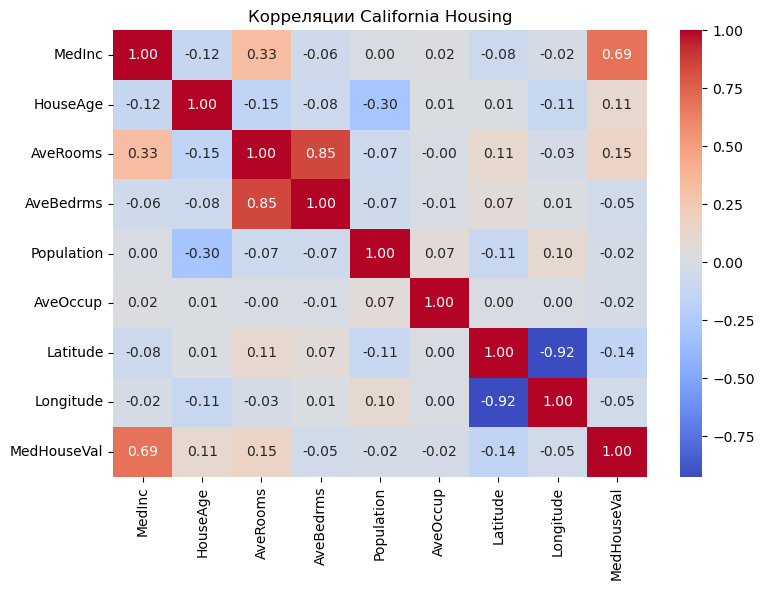

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Корреляции California Housing')
plt.tight_layout()
plt.show()


*Что мы здесь делали:* Heatmap полезно показать заказчику. Сразу видно мультиколлинеарность: `AveRooms` и `AveBedrms` сильно скоррелированы — для линрега это потенциальная проблема.

## Упражнение 3 — Split 80/20

In [4]:
print(X_train.shape, X_test.shape)


(16512, 8) (4128, 8)


*Что мы здесь делали:* Стандартный split. С `random_state=42` все получают одни и те же данные.

## Упражнение 4 — Baseline

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

*Что мы здесь делали:* Обучили линрег за одну строку. Внутри sklearn решает МНК через SVD-разложение.

## Упражнение 5 — Коэффициенты

In [6]:
coefs = pd.Series(model.coef_, index=X.columns)
coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index).round(4)
print(coefs)
print(f'\nintercept: {model.intercept_:.4f}')
# вывод: MedInc вносит положительный вклад (+ доход → дороже), Latitude/Longitude — географический эффект.


AveBedrms     0.7831
MedInc        0.4487
Longitude    -0.4337
Latitude     -0.4198
AveRooms     -0.1233
HouseAge      0.0097
AveOccup     -0.0035
Population   -0.0000
dtype: float64

intercept: -37.0233


*Что мы здесь делали:* `MedInc` ожидаемо доминирует. Коэффициенты при географии нетривиально интерпретировать в одиночку — реальный эффект района ловится их сочетанием.

## Упражнение 6 — Метрики

In [7]:
y_pred = model.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
print(f'MAE:  {mae:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'MAPE: {mape:.3f}')
print(f'R²:   {r2:.3f}')


MAE:  0.533
RMSE: 0.746
MAPE: 0.320
R²:   0.576


*Что мы здесь делали:* 4 главные метрики регрессии. R² ≈ 0.6 — для линрега на этом датасете нормально. Чтобы выбить R² выше, нужны нелинейности или ансамбли.

## Упражнение 7 — y_true vs y_pred

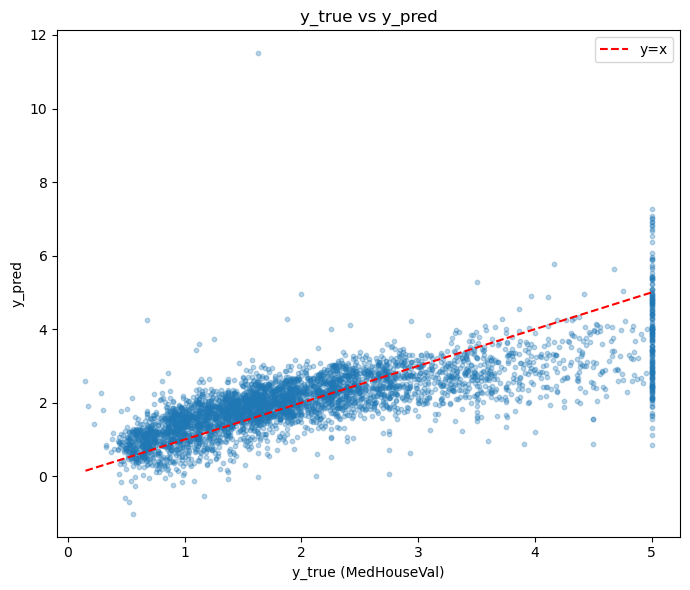

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.3, s=10)
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, 'r--', label='y=x')
ax.set_xlabel('y_true (MedHouseVal)')
ax.set_ylabel('y_pred')
ax.set_title('y_true vs y_pred')
ax.legend()
plt.tight_layout()
plt.show()


*Что мы здесь делали:* На графике видно «потолок» y_true ≈ 5 — в исходных данных цены обрезаны на $500K. Модель про этот потолок не знает и недопредсказывает.

## Упражнение 8 — Остатки

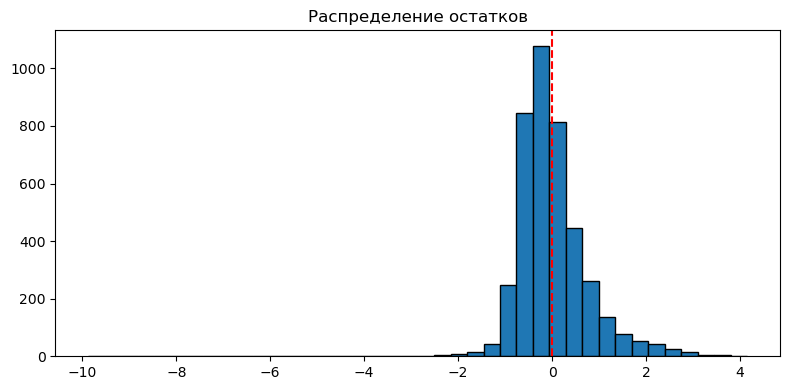

mean residual: 0.0035


In [9]:
residuals = y_test.values - y_pred
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residuals, bins=40, edgecolor='black')
ax.axvline(0, color='red', linestyle='--')
ax.set_title('Распределение остатков')
plt.tight_layout()
plt.show()
print(f'mean residual: {residuals.mean():.4f}')


*Что мы здесь делали:* Среднее остатков ~0 — это базовое требование. Распределение похоже на нормальное с небольшим скосом — типично для линрега.

## Упражнение 9 — Polynomial(2)

In [10]:
pipe2 = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(2, include_bias=False)),
    ('lin', LinearRegression()),
])
pipe2.fit(X_train, y_train)
y_pred2 = pipe2.predict(X_test)
rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
print(f'Poly(2) RMSE: {rmse2:.3f}')


Poly(2) RMSE: 0.681


*Что мы здесь делали:* Polynomial-фичи добавили взаимодействия и квадраты. RMSE упал — значит, в данных есть нелинейности.

## Упражнение 10 — K-fold сравнение

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
models = {
    'baseline':  LinearRegression(),
    'poly(2)':   Pipeline([('s', StandardScaler()), ('p', PolynomialFeatures(2, include_bias=False)), ('l', LinearRegression())]),
    'poly(3)':   Pipeline([('s', StandardScaler()), ('p', PolynomialFeatures(3, include_bias=False)), ('l', LinearRegression())]),
}
for name, m in models.items():
    scores = -cross_val_score(m, X, y, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    print(f'{name:10s} RMSE: {scores.mean():.3f} ± {scores.std():.3f}')


baseline   RMSE: 0.728 ± 0.015


poly(2)    RMSE: 5.026 ± 8.695


poly(3)    RMSE: 471.496 ± 915.835


*Что мы здесь делали:* k-fold даёт устойчивую оценку. На California Housing poly(2) обычно лучший компромисс; poly(3) даёт огромный std — переобучение на отдельных фолдах.

## Упражнение 11 — Финальная модель + сохранение

In [12]:
best = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(2, include_bias=False)),
    ('lin', LinearRegression()),
])
best.fit(X, y)
joblib.dump(best, '/tmp/my_california.pkl')
print('Saved.')


Saved.


*Что мы здесь делали:* После выбора лучшей модели по CV учим её на всех данных и сохраняем. Дальше эту pickle-модель загрузит FastAPI.

## Упражнение 12 — Загрузка и предсказание

In [13]:
loaded = joblib.load('/tmp/my_california.pkl')
new = pd.DataFrame([{
    'MedInc': 5.0, 'HouseAge': 25.0, 'AveRooms': 6.0, 'AveBedrms': 1.0,
    'Population': 1500.0, 'AveOccup': 3.0, 'Latitude': 34.0, 'Longitude': -118.0,
}])
pred = loaded.predict(new)[0]
print(f'Прогноз цены: {pred:.3f} (сотни тыс. долл.) = {pred * 100_000:,.0f} долл.')


Прогноз цены: 2.340 (сотни тыс. долл.) = 233,992 долл.


*Что мы здесь делали:* Эмулируем production-вызов. То же самое будет делать FastAPI-эндпоинт: загрузил модель в lifespan, в `/predict` собирает DataFrame из тела запроса и возвращает число.

---

Готово.